# RL Holdout Evaluation Analysis

Analysis notebook for the independent 100-seed holdout evaluation. It reads `holdout_all_evaluations.csv`, writes statistical result tables, and exports thesis figures.

In [1]:
from __future__ import annotations

from math import sqrt
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'rl_holdout_evaluation.py').exists():
    BASE_DIR = Path('C:/Workspace ZHAW/6. Semester/BA/BA-Simulation-Optimization/RL')

HOLDOUT_DIR = BASE_DIR / 'results' / 'rl_holdout_results' / 'holdout_100_seeds'
SMOKE_DIR = BASE_DIR / 'results' / 'rl_holdout_results' / 'holdout_smoke_test'
if not (HOLDOUT_DIR / 'holdout_all_evaluations.csv').exists() and (SMOKE_DIR / 'holdout_all_evaluations.csv').exists():
    HOLDOUT_DIR = SMOKE_DIR

ANALYSIS_DIR = BASE_DIR / 'statistical_analysis_results' / 'holdout_100_seeds'
FIGURE_DIR = BASE_DIR.parent.parent / 'Thesis' / 'BA' / 'figures' / 'rl_results'
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = HOLDOUT_DIR / 'holdout_all_evaluations.csv'
POLICY_REGISTRY_PATH = HOLDOUT_DIR / 'policy_registry.csv'
print(f'Holdout input: {DATA_PATH}')
print(f'Analysis output: {ANALYSIS_DIR}')
print(f'Figure output: {FIGURE_DIR}')

Holdout input: c:\Workspace ZHAW\6. Semester\BA\BA-Simulation-Optimization\RL\results\rl_holdout_results\holdout_100_seeds\holdout_all_evaluations.csv
Analysis output: c:\Workspace ZHAW\6. Semester\BA\BA-Simulation-Optimization\RL\statistical_analysis_results\holdout_100_seeds
Figure output: c:\Workspace ZHAW\6. Semester\BA\Thesis\BA\figures\rl_results


In [2]:
df = pd.read_csv(DATA_PATH)
registry = pd.read_csv(POLICY_REGISTRY_PATH) if POLICY_REGISTRY_PATH.exists() else pd.DataFrame()

if 'error' in df.columns:
    df = df[df['error'].fillna('').astype(str).str.len() == 0].copy()

for column in ['total_reward', 'late_order_fraction', 'eval_seed', 'replication']:
    df[column] = pd.to_numeric(df[column], errors='coerce')

policy_labels = df.drop_duplicates('policy_id').set_index('policy_id')['policy_label'].to_dict()
df[['policy_id', 'policy_label', 'replication', 'eval_seed', 'total_reward', 'late_order_fraction']].head()

,policy_id,policy_label,replication,eval_seed,total_reward,late_order_fraction
0,baseline_earliest_due_date,Earliest Due Date,0,900000,-462.0,0.565217
1,baseline_earliest_due_date,Earliest Due Date,1,901000,628.0,0.374101
2,baseline_earliest_due_date,Earliest Due Date,2,902000,9.0,0.477941
3,baseline_earliest_due_date,Earliest Due Date,3,903000,-298.0,0.537415
4,baseline_earliest_due_date,Earliest Due Date,4,904000,-448.0,0.565836


In [3]:
ALPHA = 0.05
METRIC = 'total_reward'
TEST_ALTERNATIVE = 'two-sided'

def standard_error(values: pd.Series) -> float:
    values = pd.to_numeric(values, errors='coerce').dropna()
    if len(values) <= 1:
        return float('nan')
    return float(values.std(ddof=1) / sqrt(len(values)))

def describe_reward(values: pd.Series) -> dict[str, float | int]:
    values = pd.to_numeric(values, errors='coerce').dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    return {
        'n': int(len(values)),
        'total_reward_mean': float(values.mean()),
        'total_reward_se': standard_error(values),
        'total_reward_median': float(values.median()),
        'total_reward_q1': float(q1),
        'total_reward_q3': float(q3),
        'total_reward_iqr': float(q3 - q1),
        'total_reward_min': float(values.min()),
        'total_reward_max': float(values.max()),
    }

def holm_bonferroni(p_values: list[float]) -> list[float]:
    m = len(p_values)
    ordered = sorted(enumerate(p_values), key=lambda item: item[1])
    adjusted = [float('nan')] * m
    running_max = 0.0
    for rank, (original_index, p_value) in enumerate(ordered, start=1):
        corrected = min((m - rank + 1) * p_value, 1.0)
        running_max = max(running_max, corrected)
        adjusted[original_index] = running_max
    return adjusted

def paired_wilcoxon(first: pd.Series, second: pd.Series, first_name: str, second_name: str, comparison: str) -> dict[str, object]:
    first = pd.to_numeric(first, errors='coerce')
    second = pd.to_numeric(second, errors='coerce')
    valid = pd.DataFrame({'first': first, 'second': second}).dropna()
    differences = valid['first'] - valid['second']
    try:
        test = stats.wilcoxon(valid['first'], valid['second'], alternative=TEST_ALTERNATIVE)
        statistic = float(test.statistic)
        p_value = float(test.pvalue)
    except ValueError:
        statistic = 0.0
        p_value = 1.0
    return {
        'comparison': comparison,
        'metric': METRIC,
        'first_group': first_name,
        'second_group': second_name,
        'n_pairs': int(len(valid)),
        'mean_first': float(valid['first'].mean()),
        'mean_second': float(valid['second'].mean()),
        'standard_error_first': standard_error(valid['first']),
        'standard_error_second': standard_error(valid['second']),
        'median_first': float(valid['first'].median()),
        'median_second': float(valid['second'].median()),
        'q1_first': float(valid['first'].quantile(0.25)),
        'q1_second': float(valid['second'].quantile(0.25)),
        'q3_first': float(valid['first'].quantile(0.75)),
        'q3_second': float(valid['second'].quantile(0.75)),
        'iqr_first': float(valid['first'].quantile(0.75) - valid['first'].quantile(0.25)),
        'iqr_second': float(valid['second'].quantile(0.75) - valid['second'].quantile(0.25)),
        'mean_difference_first_minus_second': float(differences.mean()),
        'standard_error_difference': standard_error(differences),
        'median_difference_first_minus_second': float(differences.median()),
        'test': 'Wilcoxon signed-rank',
        'alternative': TEST_ALTERNATIVE,
        'test_statistic': statistic,
        'p_value': p_value,
        'alpha': ALPHA,
        'significant': bool(p_value < ALPHA),
    }

def paired_policy_test(first_policy: str, second_policy: str, comparison: str) -> dict[str, object] | None:
    available = set(df['policy_id'])
    if first_policy not in available or second_policy not in available:
        return None
    paired = df[df['policy_id'].isin([first_policy, second_policy])].pivot_table(
        index='eval_seed', columns='policy_id', values=METRIC, aggfunc='first'
    ).dropna()
    if paired.empty:
        return None
    return paired_wilcoxon(
        paired[first_policy],
        paired[second_policy],
        policy_labels.get(first_policy, first_policy),
        policy_labels.get(second_policy, second_policy),
        comparison,
    )

def save_tests(rows: list[dict[str, object]], path: Path, holm: bool = False) -> pd.DataFrame:
    out = pd.DataFrame(rows)
    if holm and not out.empty:
        out['p_value_holm'] = holm_bonferroni(out['p_value'].astype(float).tolist())
        out['significant_holm'] = out['p_value_holm'] < ALPHA
    out.to_csv(path, index=False)
    return out

In [4]:
descriptive_rows = []
for policy_id, group in df.groupby('policy_id'):
    row = {
        'policy_id': policy_id,
        'policy_label': policy_labels.get(policy_id, policy_id),
        'policy_group': group['policy_group'].iloc[0] if 'policy_group' in group else '',
    }
    row.update(describe_reward(group['total_reward']))
    late = pd.to_numeric(group['late_order_fraction'], errors='coerce').dropna()
    row.update({
        'late_order_fraction_mean': float(late.mean()),
        'late_order_fraction_se': standard_error(late),
        'late_order_fraction_median': float(late.median()),
    })
    descriptive_rows.append(row)

descriptives = pd.DataFrame(descriptive_rows).sort_values('total_reward_mean', ascending=False)
descriptives.to_csv(ANALYSIS_DIR / 'holdout_policy_descriptives.csv', index=False)
descriptives

,policy_id,policy_label,policy_group,n,total_reward_mean,total_reward_se,total_reward_median,total_reward_q1,total_reward_q3,total_reward_iqr,total_reward_min,total_reward_max,late_order_fraction_mean,late_order_fraction_se,late_order_fraction_median
10,manual_fixed120,Manual Q-learning fixed120,manual_q_learning,100,224.59,30.621060,218.5,12.25,435.25,423.00,-557.0,876.0,0.443895,0.005370,0.443103
3,baseline_highest_lateness_risk_fixed120,Highest Lateness Risk fixed120,baseline_fixed120,100,223.19,29.926201,257.0,20.00,414.25,394.25,-397.0,848.0,0.444184,0.005242,0.438399
6,bo_tuned_fixed758,BO-tuned Q-learning fixed758,bo_tuned_q_learning,100,223.19,30.688427,237.0,13.25,438.25,425.00,-497.0,876.0,0.444153,0.005381,0.441614
2,baseline_highest_lateness_risk,Highest Lateness Risk,baseline_fixed758,100,223.19,29.926201,257.0,20.00,414.25,394.25,-397.0,848.0,0.444184,0.005242,0.438399
8,bo_tuned_gamma_low,BO-tuned Q-learning gamma_low,bo_tuned_q_learning,100,221.59,31.012904,237.5,10.00,435.25,425.25,-517.0,876.0,0.444438,0.005434,0.442062
7,bo_tuned_gamma_high,BO-tuned Q-learning gamma_high,bo_tuned_q_learning,100,218.79,30.968424,237.5,10.00,435.25,425.25,-517.0,876.0,0.444937,0.005425,0.442062
5,bo_tuned_fixed120,BO-tuned Q-learning fixed120,bo_tuned_q_learning,100,210.99,29.937978,192.5,12.25,407.50,395.25,-477.0,848.0,0.446307,0.005258,0.447657
11,manual_fixed758,Manual Q-learning fixed758,manual_q_learning,100,208.59,30.283202,215.5,-0.75,412.75,413.50,-497.0,808.0,0.446734,0.005313,0.445653
9,bo_tuned_joint100,BO-tuned Q-learning joint100,bo_tuned_q_learning,100,207.99,30.243609,206.5,-16.75,419.25,436.00,-477.0,808.0,0.446842,0.005309,0.448088
12,manual_standard,Manual Q-learning standard,manual_q_learning,100,33.19,29.887529,48.5,-155.25,244.75,400.00,-717.0,643.0,0.477995,0.005259,0.474462


In [13]:
h4_row = paired_policy_test(
    'bo_tuned_fixed758',
    'manual_fixed758',
    'H4 holdout: BO-tuned fixed758 vs manual fixed758',
)
h4 = save_tests(
    [] if h4_row is None else [h4_row],
    ANALYSIS_DIR / 'holdout_h4_tuned_fixed758_vs_manual_fixed758.csv',
)

reference_policies = [
    'baseline_fifo',
    'baseline_earliest_due_date',
    'baseline_longest_waiting_time',
    'baseline_highest_lateness_risk',
    'baseline_highest_lateness_risk_fixed120',
    'random_agent',
    'manual_fixed758',
]
rows = []
for reference in reference_policies:
    row = paired_policy_test('bo_tuned_fixed758', reference, f'BO-tuned fixed758 vs {reference}')
    if row is not None:
        rows.append(row)
tuned_vs_references = save_tests(rows, ANALYSIS_DIR / 'holdout_tuned_fixed758_vs_references_tests.csv', holm=True)

rows = []
for reference in reference_policies[:-1]:
    row = paired_policy_test('manual_fixed758', reference, f'Manual fixed758 vs {reference}')
    if row is not None:
        rows.append(row)
manual_vs_references = save_tests(rows, ANALYSIS_DIR / 'holdout_manual_fixed758_vs_references_tests.csv', holm=True)

display(h4)
display(tuned_vs_references)
display(manual_vs_references)

,comparison,metric,first_group,second_group,n_pairs,mean_first,mean_second,standard_error_first,standard_error_second,median_first,...,iqr_second,mean_difference_first_minus_second,standard_error_difference,median_difference_first_minus_second,test,alternative,test_statistic,p_value,alpha,significant
0,H4 holdout: BO-tuned fixed758 vs manual fixed758,total_reward,BO-tuned Q-learning fixed758,Manual Q-learning fixed758,100,223.19,208.59,30.688427,30.283202,237.0,...,413.5,14.6,4.078572,0.0,Wilcoxon signed-rank,two-sided,423.0,0.000405,0.05,True


,comparison,metric,first_group,second_group,n_pairs,mean_first,mean_second,standard_error_first,standard_error_second,median_first,...,standard_error_difference,median_difference_first_minus_second,test,alternative,test_statistic,p_value,alpha,significant,p_value_holm,significant_holm
0,BO-tuned fixed758 vs baseline_fifo,total_reward,BO-tuned Q-learning fixed758,FIFO,100,223.19,-12.21,30.688427,29.336719,237.0,...,7.439208,220.0,Wilcoxon signed-rank,two-sided,0.0,3.612738e-18,0.05,True,2.167643e-17,True
1,BO-tuned fixed758 vs baseline_earliest_due_date,total_reward,BO-tuned Q-learning fixed758,Earliest Due Date,100,223.19,-108.61,30.688427,29.343355,237.0,...,10.472070,320.0,Wilcoxon signed-rank,two-sided,0.0,5.462856e-18,0.05,True,2.167643e-17,True
2,BO-tuned fixed758 vs baseline_longest_waiting_...,total_reward,BO-tuned Q-learning fixed758,Longest Waiting Time,100,223.19,-12.21,30.688427,29.336719,237.0,...,7.439208,220.0,Wilcoxon signed-rank,two-sided,0.0,3.612738e-18,0.05,True,2.167643e-17,True
3,BO-tuned fixed758 vs baseline_highest_lateness...,total_reward,BO-tuned Q-learning fixed758,Highest Lateness Risk,100,223.19,223.19,30.688427,29.926201,237.0,...,4.840903,0.0,Wilcoxon signed-rank,two-sided,1184.0,8.860146e-01,0.05,False,8.860146e-01,False
4,BO-tuned fixed758 vs random_agent,total_reward,BO-tuned Q-learning fixed758,Random agent,100,223.19,-26.01,30.688427,29.415352,237.0,...,10.015826,260.0,Wilcoxon signed-rank,two-sided,0.0,5.402667e-18,0.05,True,2.167643e-17,True
5,BO-tuned fixed758 vs manual_fixed758,total_reward,BO-tuned Q-learning fixed758,Manual Q-learning fixed758,100,223.19,208.59,30.688427,30.283202,237.0,...,4.078572,0.0,Wilcoxon signed-rank,two-sided,423.0,4.052571e-04,0.05,True,8.105142e-04,True


,comparison,metric,first_group,second_group,n_pairs,mean_first,mean_second,standard_error_first,standard_error_second,median_first,...,standard_error_difference,median_difference_first_minus_second,test,alternative,test_statistic,p_value,alpha,significant,p_value_holm,significant_holm
0,Manual fixed758 vs baseline_fifo,total_reward,Manual Q-learning fixed758,FIFO,100,208.59,-12.21,30.283202,29.336719,215.5,...,7.632572,220.0,Wilcoxon signed-rank,two-sided,0.0,3.592333e-18,0.05,True,1.796166e-17,True
1,Manual fixed758 vs baseline_earliest_due_date,total_reward,Manual Q-learning fixed758,Earliest Due Date,100,208.59,-108.61,30.283202,29.343355,215.5,...,10.386549,320.0,Wilcoxon signed-rank,two-sided,0.0,5.361033e-18,0.05,True,1.796166e-17,True
2,Manual fixed758 vs baseline_longest_waiting_time,total_reward,Manual Q-learning fixed758,Longest Waiting Time,100,208.59,-12.21,30.283202,29.336719,215.5,...,7.632572,220.0,Wilcoxon signed-rank,two-sided,0.0,3.592333e-18,0.05,True,1.796166e-17,True
3,Manual fixed758 vs baseline_highest_lateness_risk,total_reward,Manual Q-learning fixed758,Highest Lateness Risk,100,208.59,223.19,30.283202,29.926201,215.5,...,5.852428,-20.0,Wilcoxon signed-rank,two-sided,1001.5,4.399425e-03,0.05,True,4.399425e-03,True
4,Manual fixed758 vs random_agent,total_reward,Manual Q-learning fixed758,Random agent,100,208.59,-26.01,30.283202,29.415352,215.5,...,10.129884,240.0,Wilcoxon signed-rank,two-sided,4.0,4.193278e-18,0.05,True,1.796166e-17,True


In [14]:
tuned_variants = [
    'bo_tuned_joint100',
    'bo_tuned_fixed120',
    'bo_tuned_fixed758',
    'bo_tuned_gamma_high',
    'bo_tuned_gamma_low',
]
tuning_variant_descriptives = descriptives[descriptives['policy_id'].isin(tuned_variants)].copy()
tuning_variant_descriptives.to_csv(ANALYSIS_DIR / 'holdout_tuning_variant_descriptives.csv', index=False)

rows = []
for variant in [policy for policy in tuned_variants if policy != 'bo_tuned_fixed758']:
    row = paired_policy_test('bo_tuned_fixed758', variant, f'BO-tuned fixed758 vs {variant}')
    if row is not None:
        rows.append(row)
tuned_variant_tests = save_tests(
    rows,
    ANALYSIS_DIR / 'holdout_tuned_fixed758_vs_other_tuned_variants_tests.csv',
    holm=True,
)

display(tuning_variant_descriptives)
display(tuned_variant_tests)

,policy_id,policy_label,policy_group,n,total_reward_mean,total_reward_se,total_reward_median,total_reward_q1,total_reward_q3,total_reward_iqr,total_reward_min,total_reward_max,late_order_fraction_mean,late_order_fraction_se,late_order_fraction_median
5,bo_tuned_fixed758,BO-tuned Q-learning fixed758,bo_tuned_q_learning,100,223.19,30.688427,237.0,13.25,438.25,425.00,-497.0,876.0,0.444153,0.005381,0.441614
7,bo_tuned_gamma_low,BO-tuned Q-learning gamma_low,bo_tuned_q_learning,100,221.59,31.012904,237.5,10.00,435.25,425.25,-517.0,876.0,0.444438,0.005434,0.442062
6,bo_tuned_gamma_high,BO-tuned Q-learning gamma_high,bo_tuned_q_learning,100,218.79,30.968424,237.5,10.00,435.25,425.25,-517.0,876.0,0.444937,0.005425,0.442062
4,bo_tuned_fixed120,BO-tuned Q-learning fixed120,bo_tuned_q_learning,100,210.99,29.937978,192.5,12.25,407.50,395.25,-477.0,848.0,0.446307,0.005258,0.447657
8,bo_tuned_joint100,BO-tuned Q-learning joint100,bo_tuned_q_learning,100,207.99,30.243609,206.5,-16.75,419.25,436.00,-477.0,808.0,0.446842,0.005309,0.448088


,comparison,metric,first_group,second_group,n_pairs,mean_first,mean_second,standard_error_first,standard_error_second,median_first,...,standard_error_difference,median_difference_first_minus_second,test,alternative,test_statistic,p_value,alpha,significant,p_value_holm,significant_holm
0,BO-tuned fixed758 vs bo_tuned_joint100,total_reward,BO-tuned Q-learning fixed758,BO-tuned Q-learning joint100,100,223.19,207.99,30.688427,30.243609,237.0,...,4.672032,0.0,Wilcoxon signed-rank,two-sided,808.5,0.000974,0.05,True,0.003896,True
1,BO-tuned fixed758 vs bo_tuned_fixed120,total_reward,BO-tuned Q-learning fixed758,BO-tuned Q-learning fixed120,100,223.19,210.99,30.688427,29.937978,237.0,...,4.069050,0.0,Wilcoxon signed-rank,two-sided,269.0,0.004567,0.05,True,0.013700,True
2,BO-tuned fixed758 vs bo_tuned_gamma_high,total_reward,BO-tuned Q-learning fixed758,BO-tuned Q-learning gamma_high,100,223.19,218.79,30.688427,30.968424,237.0,...,2.194207,0.0,Wilcoxon signed-rank,two-sided,162.0,0.051512,0.05,False,0.103024,False
3,BO-tuned fixed758 vs bo_tuned_gamma_low,total_reward,BO-tuned Q-learning fixed758,BO-tuned Q-learning gamma_low,100,223.19,221.59,30.688427,31.012904,237.0,...,2.063243,0.0,Wilcoxon signed-rank,two-sided,198.0,0.467250,0.05,False,0.467250,False


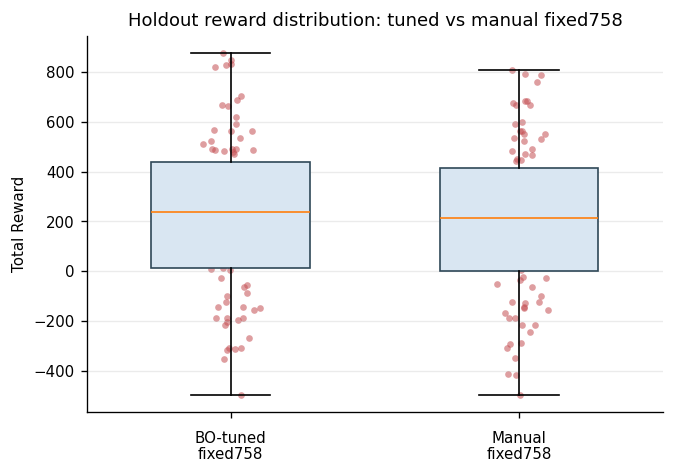

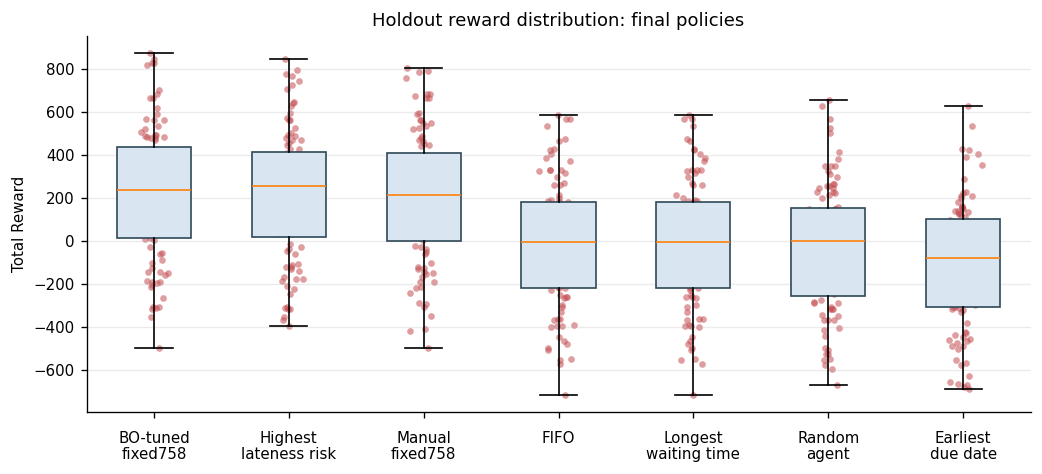

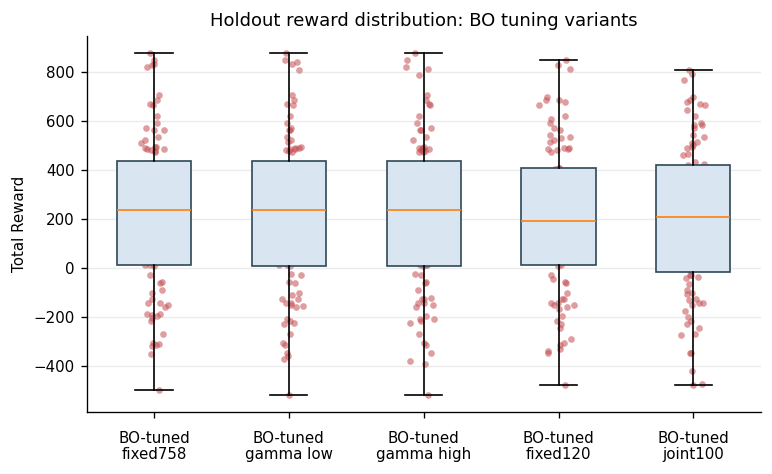

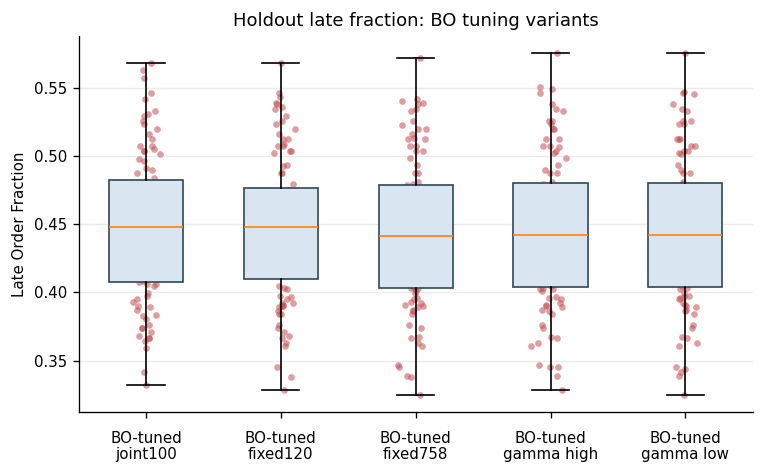

In [15]:
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SHORT_POLICY_LABELS = {
    'baseline_fifo': 'FIFO',
    'baseline_earliest_due_date': 'Earliest\ndue date',
    'baseline_longest_waiting_time': 'Longest\nwaiting time',
    'baseline_highest_lateness_risk': 'Highest\nlateness risk',
    'baseline_highest_lateness_risk_fixed120': 'Highest\nlateness risk\nfixed120',
    'random_agent': 'Random\nagent',
    'manual_standard': 'Manual\nstandard',
    'manual_fixed120': 'Manual\nfixed120',
    'manual_fixed758': 'Manual\nfixed758',
    'bo_tuned_joint100': 'BO-tuned\njoint100',
    'bo_tuned_fixed120': 'BO-tuned\nfixed120',
    'bo_tuned_fixed758': 'BO-tuned\nfixed758',
    'bo_tuned_gamma_high': 'BO-tuned\ngamma high',
    'bo_tuned_gamma_low': 'BO-tuned\ngamma low',
}

def label_for(policy_id: str, width: int = 14) -> str:
    if policy_id in SHORT_POLICY_LABELS:
        return SHORT_POLICY_LABELS[policy_id]
    return '\n'.join(textwrap.wrap(policy_labels.get(policy_id, policy_id), width=width, break_long_words=False))

def save_figure(fig: plt.Figure, stem: str) -> None:
    for suffix in ['pdf', 'png']:
        fig.savefig(FIGURE_DIR / f'{stem}.{suffix}', bbox_inches='tight')
    plt.show()

def ordered_available(policy_ids: list[str], sort_by_mean: bool = False) -> list[str]:
    available = [policy for policy in policy_ids if policy in set(df['policy_id'])]
    if sort_by_mean:
        means = df[df['policy_id'].isin(available)].groupby('policy_id')['total_reward'].mean()
        available = sorted(available, key=lambda policy: means.loc[policy], reverse=True)
    return available

def box_strip(policy_ids: list[str], stem: str, title: str, metric: str = 'total_reward', sort_by_mean: bool = False) -> None:
    policies = ordered_available(policy_ids, sort_by_mean=sort_by_mean)
    if len(policies) < 1:
        print(f'Skipping {stem}: no requested policies available.')
        return
    values = [df.loc[df['policy_id'] == policy, metric].dropna().to_numpy() for policy in policies]
    fig_width = max(6.2, 1.45 * len(policies))
    fig, ax = plt.subplots(figsize=(fig_width, 4.9))
    box = ax.boxplot(values, patch_artist=True, showfliers=False, widths=0.55)
    for patch in box['boxes']:
        patch.set_facecolor('#d9e6f2')
        patch.set_edgecolor('#2f4858')
    rng = np.random.default_rng(123)
    for idx, series in enumerate(values, start=1):
        jitter = rng.normal(0, 0.045, size=len(series))
        ax.scatter(np.full(len(series), idx) + jitter, series, s=16, alpha=0.55, color='#c44e52', linewidth=0)
    ax.set_xticks(range(1, len(policies) + 1))
    ax.set_xticklabels([label_for(policy) for policy in policies], rotation=0, ha='center', linespacing=1.05)
    ax.tick_params(axis='x', pad=8)
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)
    fig.subplots_adjust(bottom=0.24)
    save_figure(fig, stem)

final_policy_order = [
    'bo_tuned_fixed758',
    'baseline_highest_lateness_risk',
    'baseline_highest_lateness_risk_fixed120',
    'manual_fixed758',
    'baseline_fifo',
    'baseline_longest_waiting_time',
    'random_agent',
    'baseline_earliest_due_date',
]

box_strip(
    ['bo_tuned_fixed758', 'manual_fixed758'],
    'rl_holdout_tuned_vs_manual_reward_distribution',
    'Holdout reward distribution: tuned vs manual fixed758',
)
box_strip(
    final_policy_order,
    'rl_holdout_final_policy_reward_distribution',
    'Holdout reward distribution: final policies',
    sort_by_mean=True,
)
box_strip(
    tuned_variants,
    'rl_holdout_tuning_variant_reward_distribution',
    'Holdout reward distribution: BO tuning variants',
    sort_by_mean=True,
)
box_strip(
    tuned_variants,
    'rl_holdout_tuning_variant_late_fraction',
    'Holdout late fraction: BO tuning variants',
    metric='late_order_fraction',
    sort_by_mean=False,
)

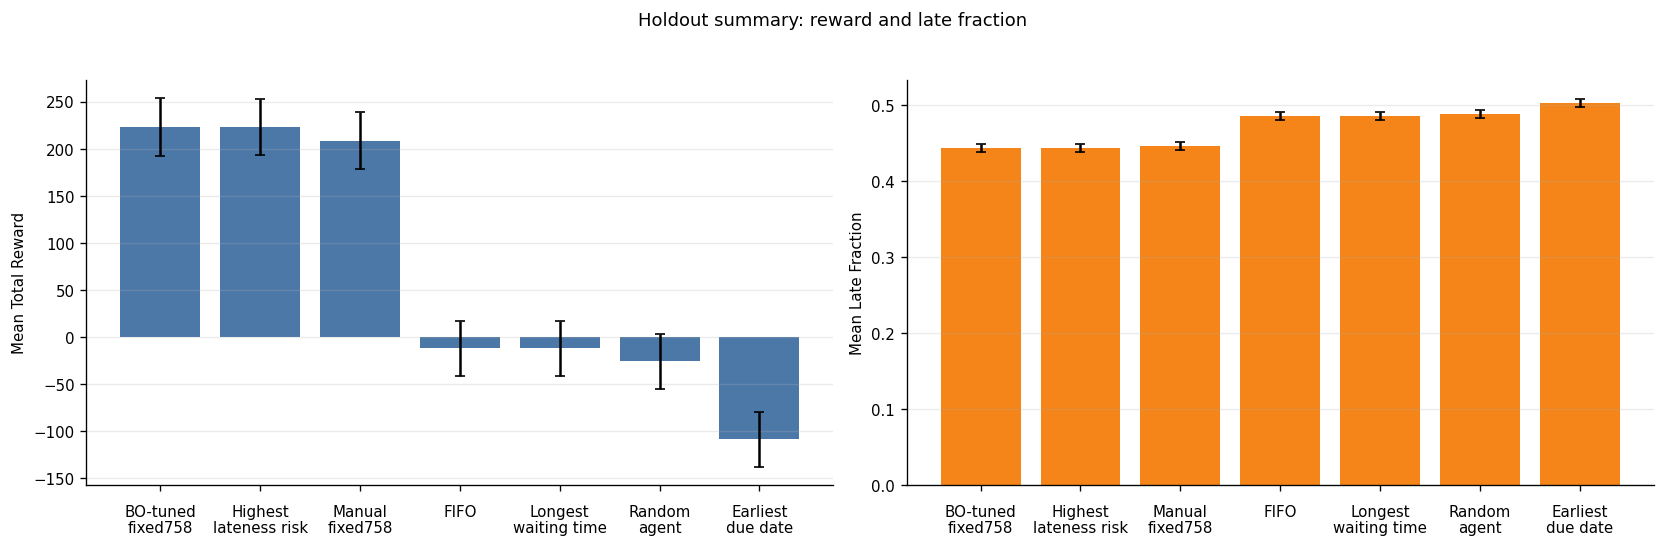

In [16]:
summary_policies = ordered_available(final_policy_order, sort_by_mean=True)
if summary_policies:
    summary = df[df['policy_id'].isin(summary_policies)].groupby('policy_id').agg(
        reward_mean=('total_reward', 'mean'),
        reward_se=('total_reward', standard_error),
        late_mean=('late_order_fraction', 'mean'),
        late_se=('late_order_fraction', standard_error),
    ).loc[summary_policies]

    fig_width = max(11.5, 1.35 * len(summary_policies) + 4.5)
    fig, axes = plt.subplots(1, 2, figsize=(fig_width, 5.0), sharex=False)
    x = np.arange(len(summary))
    labels = [label_for(policy, width=12) for policy in summary.index]

    axes[0].bar(x, summary['reward_mean'], yerr=summary['reward_se'], color='#4c78a8', capsize=3)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=0, ha='center', linespacing=1.05)
    axes[0].tick_params(axis='x', pad=8)
    axes[0].set_ylabel('Mean Total Reward')
    axes[0].grid(axis='y', alpha=0.25)

    axes[1].bar(x, summary['late_mean'], yerr=summary['late_se'], color='#f58518', capsize=3)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=0, ha='center', linespacing=1.05)
    axes[1].tick_params(axis='x', pad=8)
    axes[1].set_ylabel('Mean Late Fraction')
    axes[1].grid(axis='y', alpha=0.25)

    fig.suptitle('Holdout summary: reward and late fraction')
    fig.tight_layout(rect=[0, 0.08, 1, 0.95])
    save_figure(fig, 'rl_holdout_final_policy_summary')
else:
    print('Skipping summary figure: no final policies available.')